# Deferred-Revenue Signal — a quantitative teardown 🔬
### A point-in-time calendar-time tercile long-short (Newey-West) · a pooled event-drift cross-check with a label-shuffle placebo · an era split · the leads-future-sales regression · a 12-seed synthetic control

![Signal: Weak](https://img.shields.io/badge/Signal-Weak-dab617?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Leads sales%3F: Confirmed](https://img.shields.io/badge/Leads_sales%3F-Confirmed-8b949e?style=flat-square)

The deep companion to the [notebook for the curious](01_for_the_curious.ipynb). The claim — **deferred-revenue growth leads future sales *and* returns** — splits cleanly into two testable pieces, and the two pieces give opposite answers. This is distinct from every sibling on the desk: [199](../../199-sales-growth/) ranks on *recognised* sales growth, [534](../../534-revenue-surprise-drift/) on a *revenue surprise* event, [799](../../799-order-backlog-drift/) on *order backlog*. This is the balance-sheet **contract-liability** line.

> ⚠️ **Data note.** EDGAR `DeferredRevenueCurrent` / `ContractWithCustomerLiabilityCurrent` (longest per-name history) + yfinance adjusted closes, 40 names, ends 2009-11-27 → 2026-04-30, as-of 2026-06-30. Point-in-time on the **filing date**. Survivorship named on the Signal axis (current-survivors basket). Thin/uneven coverage is a first-class caveat. Numbers in [`docs/results.md`](../docs/results.md) (prices fingerprint `f8a44ad79534`).
>
> 💡 **The `💡 In plain words` notes** translate each result back to intuition.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from deferred_revenue import data, strategy as st

HAVE_REAL = data.have_real()
if HAVE_REAL:
    PX, EV = data.load_real()
else:
    PX = EV = None
print("real cache present:", HAVE_REAL, "| events:", (0 if EV is None else len(EV)),
      "| names:", (0 if EV is None else EV['ticker'].nunique()))

# frozen headline numbers (mirror of docs/results.md)
R = {'as_of': '2026-06-30', 'n_names': 40, 'n_events': 1238, 'end_lo': '2009-11-27', 'end_hi': '2026-04-30', 'fp_prices': 'f8a44ad79534', 'n_months': 195, 'avg_n': 19.6, 'ls_span_lo': '2010-04-30', 'ls_span_hi': '2026-06-30', 'ls_mean_bps': 56.2, 'ls_ann': 6.74, 'ls_t_iid': 1.04, 'ls_t_nw': 0.94, 'ls_sharpe': 0.26, 'ls_hit': 55, 'ls_long_bps': 230.3, 'ls_short_bps': 174.1, 'ls_turn': 0.1, 'ls_cum': 1.72, 'ls120_mean_bps': 50.8, 'ls120_t_nw': 0.84, 'scaled_mean_bps': 75.9, 'scaled_t_nw': 1.63, 'scaled_sharpe': 0.43, 'xsec_early': 8.8, 'xsec_late': 27.2, 'drift': {21: (1232, 1.25, 1.54, -0.29, -0.42, 48, 0.6676), 63: (1213, 5.7, 5.37, 0.33, 0.2, 49, 0.4062), 126: (1185, 10.15, 9.62, 0.53, 0.22, 47, 0.4096)}, 'mono63': (5.37, 5.12, 5.7), 'mono126': (9.62, 9.36, 10.15), 'era_early_n': 105, 'era_early_bps': 53.3, 'era_early_t': 0.86, 'era_late_n': 90, 'era_late_bps': 59.6, 'era_late_t': 0.55, 'ls_n': 917, 'ls_slope': 0.434, 'ls_reg_t': 27.05, 'ls_r2': 0.444, 'ls_corr': 0.667, 'ls_top_sales': 40.4, 'ls_bot_sales': 8.4, 'ls_spread': 32.0, 'contemp_corr': 0.678, 'net': {(10, 50): (49.9, 5.99, 0.83, 0.23), (20, 100): (43.7, 5.24, 0.73, 0.2)}, 'syn_null_mean': -0.35, 'syn_null_sd': 1.08, 'syn_null_fire': 1, 'syn_null_seeds': 12, 'syn_planted_bps': 236.8, 'syn_planted_t': 6.56}


real cache present: True | events: 1238 | names: 40


## Verdict, up front

| Axis | Stamp | Decisive number |
|---|---|---|
| **Signal** (returns) | `WEAK` | calendar tercile long-short **+56.2 bps/mo** (+6.7%/yr gross), one-sample *t* = +1.04, **Newey-West *t* = +0.94**; asset-scaled variant NW *t* = +1.63 — right-signed, never clears 2 |
| **Tradability** | `MIRAGE` | net of 20 bps + 100 bps borrow: NW *t* = +0.73, Sharpe 0.20; fails **before** costs |
| **Leads future sales?** | `CONFIRMED` | next-q sales-growth regression slope +0.43 (corr +0.67), top−bottom tercile spread **+32 pp** |

> 💡 In plain words: the accounting lead is bulletproof and the return edge is a near-null. A public balance-sheet number forecasts the business, and the market has already priced the stock accordingly.

## 1 · The claim, steelmanned

Let $D_{i,q}$ be name $i$'s current deferred-revenue balance at fiscal quarter $q$, disclosed on filing date $F_{i,q}$. The signal is the point-in-time YoY growth $g_{i,q} = D_{i,q}/D_{i,q-4} - 1$, known at $F_{i,q}$. The claims:

- **H₁ (leads sales).** $g_{i,q}$ predicts next quarter's recognised revenue growth $\Delta\text{Rev}_{i,q+1}$ — the accounting mechanism.
- **H₂ (leads returns).** A cross-sectional long-short on $g$ earns a positive forward return spread — the market-mispricing claim.
- **H₃ (tradable).** That spread survives realistic long-short costs + borrow.

We find **H₁ strongly supported** (slope +0.43, corr +0.67, +32 pp tercile spread), **H₂ not supported** (NW *t* = +0.94, flat non-monotone event drift), and therefore **H₃ moot** (nothing to trade). The literature (Sloan 1996; Prakash-Sinha 2013) supports a real *mispricing*; our tape supports the *mechanism* but not the *mispricing* — hence a `WEAK`, not `NONE`, on returns.

## 2 · So what? — inference design

The primary is a **calendar-time** long-short, not a pooled event study, precisely because balance-sheet signals are persistent and filings cluster: a calendar series of monthly long-short returns lets a **Newey-West (6-lag) HAC *t*** do the honest work the desk's `REAL` bar is written against. The panel is thin, so we sort into **terciles** (not quintiles) and require ≥ 6 names in the cross-section. The pooled event drift + a **label-shuffle placebo** is the cross-check; the leads-sales regression is graded on **magnitude** (its pooled *t* ignores quarter clustering, so we read the +32 pp spread and +0.67 correlation, not the literal +27).

## 3 · How we'd know — the protocol

- **Panel.** 1,238 (ticker, filing) deferred-revenue quarters across 40 names, ends 2009-11-27 → 2026-04-30, each stamped with its 10-Q/10-K filing date (point-in-time).
- **Primary.** Monthly tercile long-short on `defrev_yoy`, one execution lag (rank at month $M$ close, earn month $M{+}1$); Newey-West + one-sample *t*, Sharpe, hit rate.
- **Cross-check.** Pooled event drift over 21/63/126 trading days, one-day-lag entry, top-minus-bottom tercile, one-sample *t* + 10k-draw label-shuffle placebo, and the tercile monotonicity picture.
- **Robustness.** Staleness 120 vs 200 days; the asset-scaled signal `(ΔDefRev)/Assets`; an era split at 2019 (when the SaaS cohort widens the panel).
- **Mechanism.** Pooled OLS of next-quarter revenue growth on `defrev_yoy`.
- **Execution.** Long-short net of one-way cost × turnover (both legs) + short borrow.
- **Control.** Synthetic panel, planted-lead knob; the null must not fire across 12 seeds.

## 4 · The teardown

### 4a · The primary — calendar-time tercile long-short (Newey-West)

Rank fresh signals into terciles each month, long top / short bottom equal-weight, earn next month's return. The decisive statistic is the HAC *t* of the monthly long-short series.

calendar long-short: +56.2 bps/mo (+6.74%/yr gross), n=195 months, avg cross-section 19.6
  one-sample t = +1.04   Newey-West(6) t = +0.94   Sharpe 0.26   hit 55%   turnover 0.10
  asset-scaled signal: +75.9 bps/mo, NW t = +1.63, Sharpe 0.43


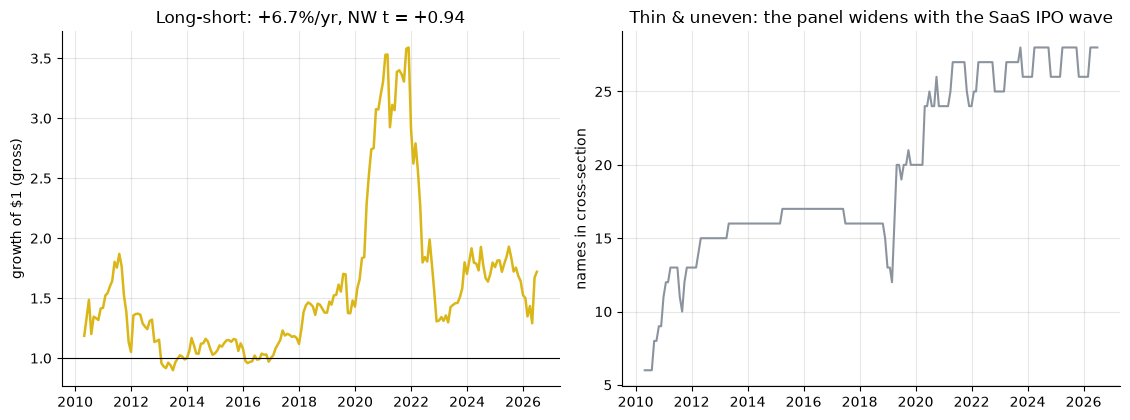

frozen: +56.2 bps/mo, NW t = +0.94, staleness-120 NW t = +0.84, asset-scaled NW t = +1.63


In [2]:
if HAVE_REAL:
    ls = st.calendar_ls(PX, EV, signal_col='defrev_yoy', n_buckets=3, min_names=6, staleness_days=200)
    s = st.calendar_ls_stats(ls)
    ls_sc = st.calendar_ls(PX, EV, signal_col='defrev_chg_assets', n_buckets=3, min_names=6, staleness_days=200)
    s_sc = st.calendar_ls_stats(ls_sc)
    print(f"calendar long-short: {s['mean_bps']:+.1f} bps/mo (+{s['ann_pct']:.2f}%/yr gross), "
          f"n={s['n_months']} months, avg cross-section {s['avg_n']:.1f}")
    print(f"  one-sample t = {s['t_iid']:+.2f}   Newey-West(6) t = {s['t_nw']:+.2f}   "
          f"Sharpe {s['sharpe']:.2f}   hit {s['hit']*100:.0f}%   turnover {s['avg_turnover']:.2f}")
    print(f"  asset-scaled signal: {s_sc['mean_bps']:+.1f} bps/mo, NW t = {s_sc['t_nw']:+.2f}, Sharpe {s_sc['sharpe']:.2f}")
    cum = (1+ls['ls']).cumprod(); nser = ls['n']
else:
    cum = None; nser = None
fig, (a1, a2) = plt.subplots(1, 2, figsize=(11.4, 4.3))
if cum is not None:
    a1.plot(cum.index, cum.values, color=AMBER, lw=1.8); a1.axhline(1, c='k', lw=.8)
    a1.set_ylabel('growth of $1 (gross)'); a1.set_title(f"Long-short: +{R['ls_ann']:.1f}%/yr, NW t = {R['ls_t_nw']:+.2f}")
    a2.plot(nser.index, nser.values, color=GREY, lw=1.5); a2.set_ylabel('names in cross-section')
    a2.set_title('Thin & uneven: the panel widens with the SaaS IPO wave')
else:
    for a in (a1,a2): a.text(.5,.5,'run with cache',ha='center'); a.set_axis_off()
plt.tight_layout(); plt.show()
print(f"frozen: {R['ls_mean_bps']:+.1f} bps/mo, NW t = {R['ls_t_nw']:+.2f}, "
      f"staleness-120 NW t = {R['ls120_t_nw']:+.2f}, asset-scaled NW t = {R['scaled_t_nw']:+.2f}")

> 💡 In plain words: **+56 bps/month** is economically real money (~+6.7%/yr gross), but the HAC *t* is **+0.94** — the monthly returns are too noisy and too few (n=195, avg cross-section 20) to distinguish from zero. Every specification agrees: staleness-120 NW *t* = +0.84, and the best case — the asset-scaled signal — tops out at NW *t* = +1.63. Right-signed, never certified.

### 4b · The cross-check — pooled event drift + placebo + monotonicity

Bucket all events by signal; top-minus-bottom forward drift with a label-shuffle null. If there were a sort, the terciles would form a ladder.

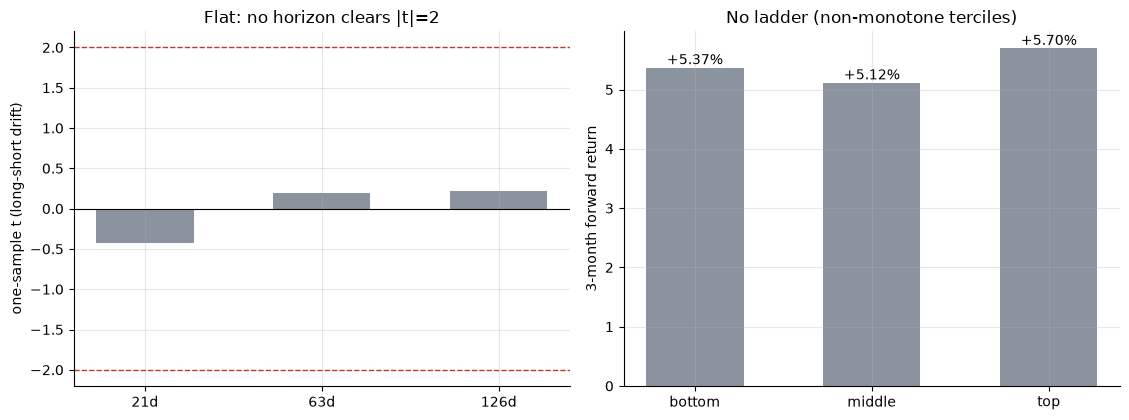

  H= 21d: long-short -0.29%  t=-0.42  win=48%  placebo p=0.669
  H= 63d: long-short +0.33%  t=+0.20  win=49%  placebo p=0.404
  H=126d: long-short +0.53%  t=+0.22  win=47%  placebo p=0.410


In [3]:
rows = []
if HAVE_REAL:
    for h in st.HORIZONS:
        es = st.event_summary(PX, EV, horizon=h, n_buckets=3, n_draws=4000)
        rows.append((h, es['ls_mean']*100, es['t'], es['ls_win']*100, es['p_placebo']))
    mono = st.bucket_means(st.event_drift_frame(PX, EV, horizon=63), 3)*100
else:
    for h in st.HORIZONS:
        d = R['drift'][h]; rows.append((h, d[3], d[4], d[5], d[6]))
    mono = np.array(R['mono63'])
fig, (a1, a2) = plt.subplots(1, 2, figsize=(11.4, 4.3))
hs = [r[0] for r in rows]; ts = [r[2] for r in rows]
a1.bar([f'{h}d' for h in hs], ts, color=GREY, width=.55)
a1.axhline(2, ls='--', c=RED, lw=1); a1.axhline(-2, ls='--', c=RED, lw=1); a1.axhline(0, c='k', lw=.8)
a1.set_ylabel('one-sample t (long-short drift)'); a1.set_title('Flat: no horizon clears |t|=2')
a2.bar(['bottom','middle','top'], mono, color=GREY, width=.55)
for i,v in enumerate(mono): a2.annotate(f'{v:+.2f}%',(i,v),ha='center',va='bottom')
a2.set_ylabel('3-month forward return'); a2.set_title('No ladder (non-monotone terciles)')
plt.tight_layout(); plt.show()
for h,ls_,t,win,p in rows:
    print(f'  H={h:>3}d: long-short {ls_:+.2f}%  t={t:+.2f}  win={win:.0f}%  placebo p={p:.3f}')

> 💡 In plain words: the pooled long-short drift is **flat** at every horizon (*t* from -0.42 to +0.22), the label-shuffle placebo *p* sits around **0.4** (a random tercile split beats the real one ~4 times in 10), and the terciles are **non-monotone** (+5.37% / +5.12% / +5.70% low→high at 63d). The event study and the calendar long-short agree: no return sort.

### 4c · Era split — nothing hiding in a regime

Split the calendar long-short at 2019 (the SaaS-cohort widening).

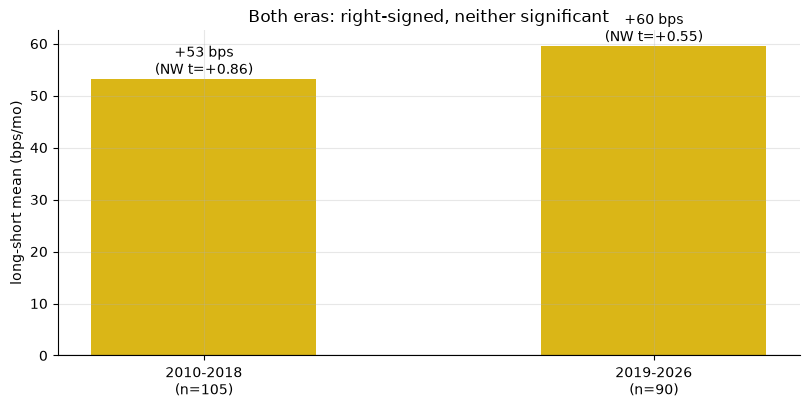

2010-2018: +53.3 bps NW t=+0.86 (n=105)  |  2019-2026: +59.6 bps NW t=+0.55 (n=90)


In [4]:
if HAVE_REAL:
    e = ls[ls.index < '2019-01-01']['ls'].to_numpy(); l = ls[ls.index >= '2019-01-01']['ls'].to_numpy()
    eb, et, en = e.mean()*1e4, st.newey_west_t(e), len(e)
    lb, lt, ln = l.mean()*1e4, st.newey_west_t(l), len(l)
else:
    eb, et, en = R['era_early_bps'], R['era_early_t'], R['era_early_n']
    lb, lt, ln = R['era_late_bps'], R['era_late_t'], R['era_late_n']
fig, ax = plt.subplots(figsize=(8.2, 4.2))
ax.bar([f'2010-2018\n(n={en})', f'2019-2026\n(n={ln})'], [eb, lb], color=[AMBER, AMBER], width=.5)
for i,(v,t_) in enumerate([(eb,et),(lb,lt)]): ax.annotate(f'{v:+.0f} bps\n(NW t={t_:+.2f})',(i,v),ha='center',va='bottom')
ax.axhline(0, c='k', lw=.8); ax.set_ylabel('long-short mean (bps/mo)')
ax.set_title('Both eras: right-signed, neither significant')
plt.tight_layout(); plt.show()
print(f'2010-2018: {eb:+.1f} bps NW t={et:+.2f} (n={en})  |  2019-2026: {lb:+.1f} bps NW t={lt:+.2f} (n={ln})')

> 💡 In plain words: +53 bps (NW *t* = +0.86) early, +60 bps (NW *t* = +0.55) late — the same right-signed-but-insignificant positive in both halves. It wasn't a live edge that decayed; it never certified.

### 4d · The mechanism — deferred revenue *does* lead sales

Pooled OLS of next-quarter revenue growth on this quarter's deferred-revenue growth, and the future-sales spread between the top and bottom deferred-growth terciles.

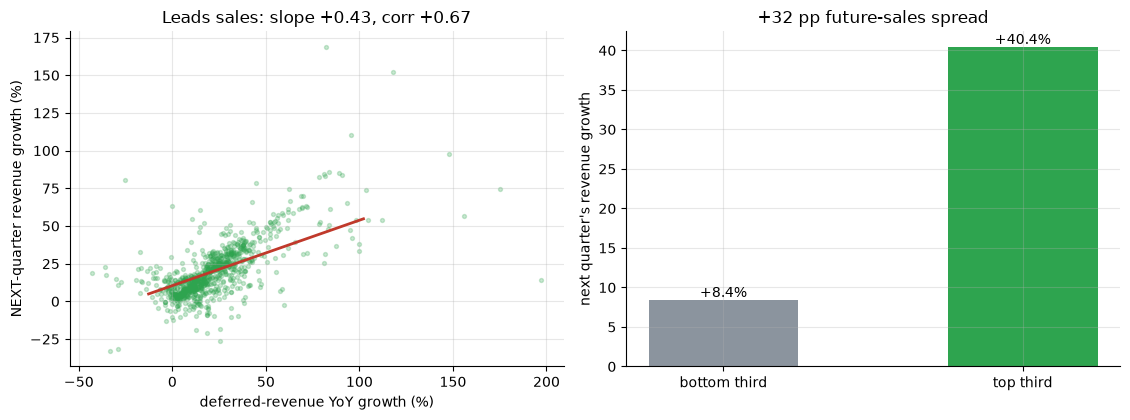

leads-sales: slope +0.434, corr +0.667, future-sales spread +32.0 pp (top +40.4% vs bottom +8.4%)


In [5]:
if HAVE_REAL:
    q = st.leads_sales(EV)
    fr = EV.dropna(subset=['defrev_yoy','next_rev_yoy'])
    x, y = fr['defrev_yoy'].to_numpy(), fr['next_rev_yoy'].to_numpy()
    slope, corr, top, bot = q['slope'], q['corr'], q['top_sales']*100, q['bot_sales']*100
else:
    x = y = None
    slope, corr, top, bot = R['ls_slope'], R['ls_corr'], R['ls_top_sales'], R['ls_bot_sales']
fig, (a1, a2) = plt.subplots(1, 2, figsize=(11.4, 4.3))
if x is not None:
    m = (np.abs(x)<2)&(np.abs(y)<3)
    a1.scatter(x[m]*100, y[m]*100, s=8, alpha=.25, color=GREEN)
    xs = np.linspace(np.percentile(x,2), np.percentile(x,98), 50)
    a1.plot(xs*100, (q['slope']*xs + (y.mean()-q['slope']*x.mean()))*100, color=RED, lw=2)
    a1.set_xlabel('deferred-revenue YoY growth (%)'); a1.set_ylabel('NEXT-quarter revenue growth (%)')
    a1.set_title(f'Leads sales: slope {slope:+.2f}, corr {corr:+.2f}')
else:
    a1.text(.5,.5,'run with cache',ha='center'); a1.set_axis_off()
a2.bar(['bottom third','top third'], [bot, top], color=[GREY, GREEN], width=.5)
for i,v in enumerate([bot, top]): a2.annotate(f'{v:+.1f}%',(i,v),ha='center',va='bottom')
a2.set_ylabel("next quarter's revenue growth"); a2.set_title(f'+{top-bot:.0f} pp future-sales spread')
plt.tight_layout(); plt.show()
print(f'leads-sales: slope {slope:+.3f}, corr {corr:+.3f}, future-sales spread {top-bot:+.1f} pp (top {top:+.1f}% vs bottom {bot:+.1f}%)')

> 💡 In plain words: this is the study's one unambiguous result — deferred-revenue growth **leads recognised sales** with correlation **+0.67** and a **+32 pp** top-minus-bottom spread in next-quarter revenue growth. The accounting mechanism is exactly as advertised. The return null is therefore not a data problem — it's a **market-efficiency** result: the lead is public and priced. (The regression *t* is huge but pooled across clustered filings; we cite the magnitude, not the *t*.)

### 4e · Tradability — the timer

For completeness, the calendar long-short net of one-way costs × turnover (both legs) + short borrow — though a sub-2 gross *t* already settles it.

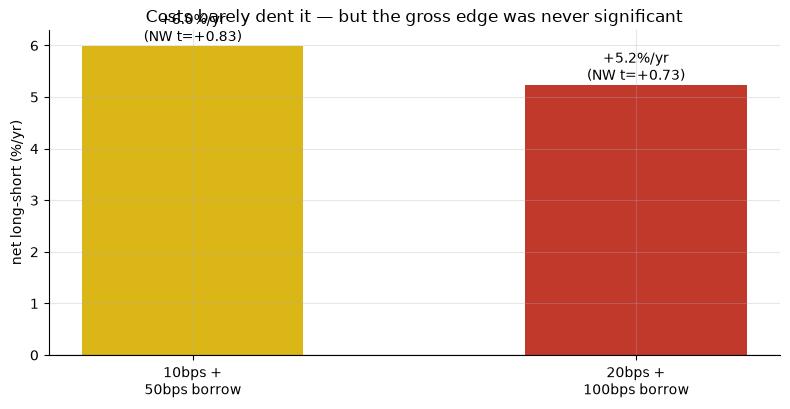

  cost 10bps + borrow 50bps/yr: +5.99%/yr net, NW t=+0.83, Sharpe 0.23
  cost 20bps + borrow 100bps/yr: +5.24%/yr net, NW t=+0.73, Sharpe 0.20


In [6]:
rows = []
if HAVE_REAL:
    for cb, bb in [(10.0,50.0),(20.0,100.0)]:
        nt = st.calendar_ls_net(ls, cost_bps=cb, borrow_bps_ann=bb)
        rows.append((cb, bb, nt['net_ann_pct'], nt['net_t_nw'], nt['net_sharpe']))
else:
    for (cb,bb),v in R['net'].items(): rows.append((cb, bb, v[1], v[2], v[3]))
labels = [f'{int(cb)}bps +\n{int(bb)}bps borrow' for cb,bb,_,_,_ in rows]
anns = [r[2] for r in rows]
fig, ax = plt.subplots(figsize=(8.0, 4.2))
ax.bar(labels, anns, color=[AMBER, RED], width=.5)
for i,(cb,bb,a,t,sh) in enumerate(rows): ax.annotate(f'+{a:.1f}%/yr\n(NW t={t:+.2f})',(i,a),ha='center',va='bottom')
ax.axhline(0, c='k', lw=.8); ax.set_ylabel('net long-short (%/yr)')
ax.set_title('Costs barely dent it — but the gross edge was never significant')
plt.tight_layout(); plt.show()
for cb,bb,a,t,sh in rows: print(f'  cost {int(cb)}bps + borrow {int(bb)}bps/yr: +{a:.2f}%/yr net, NW t={t:+.2f}, Sharpe {sh:.2f}')

> 💡 In plain words: turnover is low (~0.10/mo — a slow quarterly balance-sheet signal), so costs only trim ~+1.5%/yr. But that's irrelevant: net NW *t* = +0.73, and you cannot be paid for a spread that wasn't distinguishable from zero to begin with. **Tradability = MIRAGE.**

### 4f · Faithful-engine & power control

Synthetic price + signal panel with a TUNABLE planted lead (high-deferred-growth names drift up). The null (edge = 0) is checked over **12 seeds**.

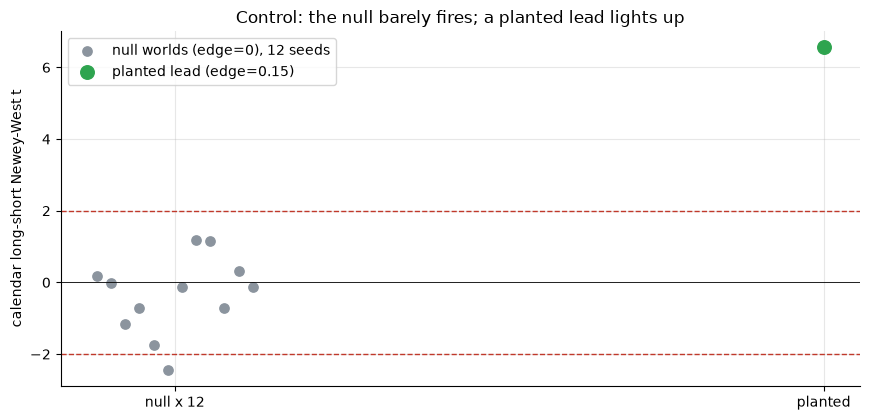

null: mean NW t = -0.35 (sd 1.08), |t|>=2 in 1/12  |  planted NW t = +6.56


In [7]:
null_ts = []
for s_ in range(12):
    p0, e0 = data.synthetic_panel(edge=0.0, seed=798 + s_)
    null_ts.append(st.synthetic_detect(p0, e0)['t_nw'])
null_ts = np.asarray(null_ts)
p1, e1 = data.synthetic_panel(edge=0.15, seed=798)
planted_t = st.synthetic_detect(p1, e1)['t_nw']
fig, ax = plt.subplots(figsize=(8.8, 4.3))
ax.scatter(np.linspace(-.12,.12,12), null_ts, color=GREY, s=45, label='null worlds (edge=0), 12 seeds')
ax.scatter([1], [planted_t], color=GREEN, s=95, zorder=5, label='planted lead (edge=0.15)')
ax.axhline(2, ls='--', c=RED, lw=1); ax.axhline(-2, ls='--', c=RED, lw=1); ax.axhline(0, c='k', lw=.6)
ax.set_xticks([0,1]); ax.set_xticklabels(['null x 12','planted'])
ax.set_ylabel('calendar long-short Newey-West t')
ax.set_title('Control: the null barely fires; a planted lead lights up'); ax.legend()
plt.tight_layout(); plt.show()
print(f'null: mean NW t = {null_ts.mean():+.2f} (sd {null_ts.std(ddof=1):.2f}), '
      f'|t|>=2 in {(abs(null_ts)>=2).sum()}/12  |  planted NW t = {planted_t:+.2f}')

> 💡 In plain words: across 12 null worlds the detector averages NW *t* = -0.35 (sd 1.08) and crosses |t|=2 only 1/12 times — about what chance gives you for a HAC *t* over ~190 months. A planted lead reads NW *t* = 6.56. The machinery is unbiased and powered, so the real-tape +0.94 is a genuine near-null, not a broken pipeline. *(Power check only — never cited in support of a real-tape stamp.)*

## 5 · The verdict

- **Signal (returns) `WEAK`** — calendar tercile long-short +56.2 bps/mo (+6.7%/yr gross), one-sample *t* = +1.04, **Newey-West *t* = +0.94**; asset-scaled best case NW *t* = +1.63; pooled event drift flat and non-monotone (placebo *p* ≈ 0.4); both eras right-signed but insignificant. Literature-supported, tape-uncertified.
- **Tradability `MIRAGE`** — net of 20 bps + 100 bps borrow: +5.24%/yr, NW *t* = +0.73, Sharpe 0.20; fails before costs.
- **Leads future sales? `CONFIRMED`** — regression slope +0.43, correlation +0.67, **+32 pp** top-minus-bottom future-sales spread. The mechanism is real; the market prices it.

## 6 · Going further

- **The residual worth chasing** is the *surprise*, not the *level*: deferred-revenue growth relative to a seasonal expectation, or relative to the sales growth analysts already model. A public level that forecasts the business but not the stock is the textbook signature of an efficiently-priced fundamental — the alpha, if any, lives in the part the market can't already see.
- **Coverage honesty:** the cross-section runs from ≈9 names (2010) to ≈27 (mid-2020s); terciles on a single-digit early cross-section are noisy, and the flat event drift across 1,200+ pooled events is the more decisive evidence of the return null.
- **Dedup map:** [199-sales-growth](../../199-sales-growth/) (recognised top-line growth, the LSV premium), [534-revenue-surprise-drift](../../534-revenue-surprise-drift/) (the seasonal-random-walk revenue *surprise* and its drift), [799-order-backlog-drift](../../799-order-backlog-drift/) (order backlog / RPO — one step earlier in the cash cycle than deferred revenue). None ranks on the contract-liability balance itself.

*The reproducible core is offline and deterministic; frozen numbers live in [`docs/results.md`](../docs/results.md), sources in [`docs/references.md`](../docs/references.md).*